In [1]:
import os
# Setează numărul de nuclee dorit (ex: 16)
n_core = "16"
os.environ["OMP_NUM_THREADS"] = n_core
os.environ["MKL_NUM_THREADS"] = n_core
os.environ["OPENBLAS_NUM_THREADS"] = n_core
os.environ["VECLIB_MAXIMUM_THREADS"] = n_core
os.environ["NUMEXPR_NUM_THREADS"] = n_core

import numpy as np
import warnings
# suppress warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import pandas as pd
import matplotlib.pyplot as plt


### Min-Max Normalization [0,1]

$$ X = \frac{x - x_\text{min}}{x_\text{max} -x_\text{min}} $$

### Codificarea Multi-Clasă (One-Hot Encoding)

Dacă avem un set de $K$ clase, transformarea unei etichete $y$ (corespunzătoare clasei $k$) într-un vector $\mathbf{v}$ se definește prin:

$$ \mathbf{v}_i = \begin{cases} 1, & \text{dacă } i = k \\ 0, & \text{dacă } i \neq k \end{cases} $$

unde $i \in \{1, \dots, K\}$.


$$g(z) = \frac{1}{1 + e^{-z}}$$
$$ \text{where z is: }\mathbf{f_{w,b}(X)}\; or\; \mathbf{f_{w,b}(X_{poly})} $$
$$ \text{The value resulting from the sigmoid function is between 0 and 1 }$$ 

$$ \text{Softmax}(z_i) = \frac{e^{(z_i - \max(z))}}{\sum_{j=1}^{K} e^{(z_j - \max(z))}} $$

**Unde:**
*  z_i : Scorul pentru clasa curentă. 
*  max(z) : Valoarea maximă din vectorul de intrare (pentru stabilitate). 
*  K : Numărul total de clase. 


#### Cost function for regularized logistic regression ( Binary Cross Entropy )

$$
J(\mathbf{w},b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(g_{\mathbf{w},b}(\mathbf{x}^{(i)})) + (1 - y^{(i)}) \log(1 - g_{\mathbf{w},b}(\mathbf{x}^{(i)})) \right]
$$

#### Cost function for regularized logistic regression ( Binary Cross Entropy )

$$J(\mathbf{w},b) = - \frac{1}{m}  \sum_{i=0}^{m-1} \left[ y^{(i)} \log\left(g_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) + \left( 1 - y^{(i)}\right) \log \left( 1 - g_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2 \tag{3}$$

$$ \text{Acuratețe} = \frac{1}{m} \sum_{i=0}^{m-1} \mathbb{1}(\hat{y}^{(i)} = y^{(i)}) $$


$$ F_1 = 2 \cdot \frac{P \cdot R}{P + R} $$

Unde:
- **P (Precizie)** = $\frac{TP}{TP + FP}$
- **R (Rapel)** = $\frac{TP}{TP + FN}$
- **TP(True Positive), FP(False Positive), FN(False Negative)**

In [2]:
# data loading
data_clean = pd.read_csv("data_clean.csv")
data_clean.shape

(9719, 17)

In [3]:
# in the case of the polynomial approach, the gain is approximately 2% in this case

# data_clean['boost_sqft_living'] = data_clean['sqft_living'].pow(2)
# data_clean['boost_floors'] = data_clean['floors'].pow(2)
# data_clean['boost_sqft_living15'] = data_clean['floors'].pow(2)
# data_clean['sqft_living_floors'] = data_clean['sqft_living'] * data_clean['floors']
# data_clean['sqft_living_sqft_living15'] = data_clean['sqft_living'] * data_clean['sqft_living15'] 
# data_clean['sqft_floors_sqft_living15'] = data_clean['floors'] * data_clean['sqft_living15'] 
# x = data_clean[[ 'floors', 'sqft_living', 'sqft_living15', 'boost_sqft_living','boost_floors', 'boost_sqft_living15', 'sqft_living_floors', 
#                  'sqft_living_sqft_living15', 'sqft_floors_sqft_living15']].to_numpy()

In [4]:

x = data_clean[[ 'floors', 'sqft_living', 'sqft_living15']].to_numpy() 


# Inițializăm scalatorul
scaler = MinMaxScaler(feature_range=(0, 1))

# Scalerul va calcula Min și Max separat pentru fiecare coloană în parte
x_norm = scaler.fit_transform(x)

print('Features shape: ', x_norm.shape)
print('Features form:')
print(x_norm[0:5,:])

Features shape:  (9719, 3)
Features form:
[[1.         0.28125    0.26142132]
 [0.         0.23958333 0.23604061]
 [1.         0.47222222 0.35025381]
 [0.         0.20833333 0.18781726]
 [1.         0.46527778 0.34771574]]


In [5]:
# extrage numarul de bedrooms
y = data_clean['bedrooms'].to_numpy()
print('Initial out form', y[0:5])
print('Minimum value bedrooms: ', np.min(y))
print('Maximum value bedrooms: ', np.max(y))
# structureaxa matricea pe verticala
y = y.reshape(*y.shape, 1)

# Inițializăm encoder-ul
encoder = OneHotEncoder(sparse_output=False) # sparse_output=False obiectul returnat este un numpy.ndarray standard

# Transformăm numerele în vectori binari
y_ended = encoder.fit_transform(y)

print('y_ended shape: ', y_ended.shape)
print('y_ended form: ')
print(y_ended[0:5,:])

Initial out form [4 3 4 3 4]
Minimum value bedrooms:  2
Maximum value bedrooms:  4
y_ended shape:  (9719, 3)
y_ended form: 
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [6]:
# impartim datele de antrenament 60% si 40% validare si testare
X_train, X_temp, Y_train, Y_temp = train_test_split(x_norm , y_ended, test_size=0.4, random_state=50)

# datele temp se inpart in validare 20% si testare 20%
X_val, X_test, Y_val, Y_test = train_test_split( X_temp, Y_temp, test_size=0.5, random_state=5)

print('Shape value for data training, validation end test')
print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

Shape value for data training, validation end test
(5831, 3) (5831, 3)
(1944, 3) (1944, 3)
(1944, 3) (1944, 3)


In [7]:
# Functia creaza pachete pentru procesare
def batch_generator(x, y, batch_size):
    
    xx = []
    yy = []
    for i in range(0, x.shape[0], batch_size):
        # Slicing-ul returnează automat un batch mai mic la final
        batch_x = x[i:i + batch_size]
        batch_y = y[i:i + batch_size]
        
        xx.append(batch_x)
        yy.append(batch_y)
    
    # Returnăm liste de array-uri (nu un singur array 3D) 
    # pentru a evita erorile de formă (shape mismatch)
    return xx, yy


In [8]:
# Creaza pachetele pentru datele de validare si antrenament 
batch = 512
train_batches_x, train_batches_y = batch_generator(X_train, Y_train, batch)
val_batches_x, val_batches_y = batch_generator(X_val, Y_val, batch)

In [9]:
""" creaza reteaua ANN pe 4 layer-ruri """
class NeuralNetwork:

    # Definim constructorul
    def __init__(self, nr_input, nr_L1, nr_L2, nr_L3):

        # Definim intrarile in model
        self.nr_input = nr_input
        self.nr_L1 = nr_L1
        self.nr_L2 = nr_L2
        self.nr_L3 = nr_L3

		# Initialize the weights
        self.w_L1 = np.random.randn(self.nr_input, self.nr_L1)
        self.w_L2 = np.random.randn(self.nr_L1, self.nr_L2)
        self.w_L3 = np.random.randn(self.nr_L2, self.nr_L3)

		# Initialize the biases
        self.bias_L1 = np.zeros((1, self.nr_L1), dtype=np.float32)
        self.bias_L2 = np.zeros((1, self.nr_L2), dtype=np.float32)
        self.bias_L3 = np.zeros((1, self.nr_L3), dtype=np.float32)


		# Datele de monitorizare
        self.cost_train = []
        self.accuracy_train = []
        self.macro_f1_train = []

        self.cost_val = []
        self.accuracy_val = []
        self.macro_f1_val = []


    # Sigmoid Function
    def sigmoid(self, x):
        x = 1/(1 + np.exp(-x))
        return x

    # Derivative of Sigmoid Function
    def derivative_sigmoid(self, x):
        dx = self.sigmoid(x)*(1-self.sigmoid(x))
        return dx

    # Functia SoftMax
    def softmax(self, x):
        e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return e_x / np.sum(e_x, axis=-1, keepdims=True)


    # Metoda de propagare in fata ( returneaza rezultare probabilistice, rezultate din SoftMax ) 
    def feedforward(self, X):
        
        self.SL1 = np.dot(X, self.w_L1) + self.bias_L1
        self.AL1 = self.sigmoid(self.SL1)
        self.SL2 = np.dot(self.AL1, self.w_L2) + self.bias_L2
        self.AL2 = self.sigmoid(self.SL2)
        self.SL3 = np.dot(self.AL2, self.w_L3) + self.bias_L3
        self.AL3 = self.softmax(self.SL3)
        return self.AL3

    # Metoda de predictie a modelului (returneaza valori categorice)
    def prediction(self, X):
        
        y_pred = self.feedforward(X)
        
        # m - numarul de exemple, n - numarul de caracteristici
        m, n = y_pred.shape

        # Gasim indexul valorii maxime pentru fiecare rand
        indices_max = np.argmax(y_pred, axis=1)

        # Cream o matrice de zerouri de aceeasi dimensiune
        y_pred_final = np.zeros((m, n))

        # Punem 1 doar la indexul maxim pe fiecare rand
        y_pred_final[np.arange(m), indices_max] = 1

        return y_pred_final

    # Metoda backpropagation pentru corectarea ponderilor
    def backward(self, X, Y, learning_rate, lambda_):

        m = Y.shape[0]# identifica numarul de exemple
        
        # define loss
        err_out = self.feedforward(X) - Y

        # define derivatele
        d_L3 = err_out 
        d_L2 = (np.dot(d_L3, self.w_L3.T)) * self.derivative_sigmoid(self.SL2)
        d_L1 = (np.dot(d_L2, self.w_L2.T)) * self.derivative_sigmoid(self.SL1)

        # define gradients 
        grad_L3 = np.dot(self.AL2.T, d_L3)
        grad_L2 = np.dot(self.AL1.T, d_L2)
        grad_L1 = np.dot(X.T, d_L1)

		# Update weights
        self.w_L3 -= (grad_L3 * learning_rate / m) + (lambda_ / m) * self.w_L3
        self.w_L2 -= (grad_L2 * learning_rate / m) + (lambda_ / m) * self.w_L2
        self.w_L1 -= (grad_L1 * learning_rate / m) + (lambda_ / m) * self.w_L1

        # Update biases
        self.bias_L3 -= np.sum(d_L3, axis=0, keepdims=True) * learning_rate 
        self.bias_L2 -= np.sum(d_L2, axis=0, keepdims=True) * learning_rate
        self.bias_L1 -= np.sum(d_L1, axis=0, keepdims=True) * learning_rate
            # axis=0 -insumeaza pe verticala
            # keepdims=True -pastrand matricea originala

    # Metoda de calcul pentru functia de cost
    def compute_cost(self, y_pred, y, lambda_):

        m = y.shape[0] # extrage numarul de exemple

        # Regularization is added to the cost function so that the performance indicator reflects exactly what the algorithm optimizes.
        # Creaza suma totala a ponderilor
        W_list = [self.w_L1, self.w_L2, self.w_L3]
        reg_sum = 0
        for W in W_list:
            reg_sum += np.sum(np.square(W))  
        # calculeaza regularizarea    
        reg_cost = (lambda_ / (2 * m)) * reg_sum

        # Cross-Entropy Loss (Eroarea pe date)
        loss = - (1/m) * np.sum(y * np.log(y_pred + 1e-15) + (1 - y) * np.log(1 - y_pred + 1e-15)) # se adăugăm 1e-15 pentru a evita log(0) care dă eroare

        # Cost Total
        total_cost = loss + reg_cost

        return total_cost

    # Metoda de calcul pentru acuratete si F1-scor
    def compute_accuracy_f1(self, y_true, y_pred):

        # y_pred este rezultatul metodei prediction(x) care returneaza 1 pe valoarea mazima returnata de SoftMax
        
        # Acuratetea
        # np.all(..., axis=1) verifică dacă tot randul este identic
        accuracy = np.mean(np.all(y_true == y_pred, axis=1))
    
        # F1-SCORE (Macro-Averaging)
        # Calculăm TP(True Positive), FP(False Positive), FN(False Negative) pentru toate coloanele simultan
        tp = np.sum((y_true == 1) & (y_pred == 1), axis=0) 
        fp = np.sum((y_true == 0) & (y_pred == 1), axis=0)
        fn = np.sum((y_true == 1) & (y_pred == 0), axis=0)
    
        # Calculam Precizia și Rapelul pentru fiecare coloană (rezultă vectori de mărime n)
        precision = tp / (tp + fp + 1e-15)  # Cate dintre cazurile prezise ca pozitive sunt cu adevărat pozitive
        recall = tp / (tp + fn + 1e-15)     # Cate dintre toate cazurile care sunt cu adevarat pozitive au fost identificate de mode
    
        # Calculam F1 pentru fiecare coloana
        f1_per_class = 2 * (precision * recall) / (precision + recall + 1e-15)
    
        # Media aritmetica a scorurilor F1 (Macro-F1)
        macro_f1 = np.mean(f1_per_class)
    
        return accuracy, macro_f1

           
    # Metoda de antrenament a modelului   
    def train(self, X, Y, X_val, Y_val, epochs, learning_rate, lambda_):

        # Functia Loop pentru antrenament
        for epoch in range(1,epochs+1):

            # Exponential Decay 
            learning_rate = learning_rate * 0.95
            # A high learning rate helps the model take large steps and quickly exit areas of high error. As it approaches the optimal solution,
            # the steps become smaller and smaller, allowing the model to "settle" exactly at the minimum point, without oscillating chaotically around it.
            
            # Weight Decay
            lambda_ = lambda_ * 1.005
            # At the beginning of training, a small lambda allows the model to learn quickly without being "slowed down" by penalties.
            # As training progresses and the risk of overfitting arises, increasing lamda forces the model to simplify the weights, keeping only the essential features.


            loss_batch_training_list = []
            accuracy_batch_training_list = []
            macro_f1_batch_training_list = []

            # Functia Loop pentru a rula pachetele din datele de antrenament
            for X_batch_train, Y_batch_train in zip(X,Y):
                # Lanseaza metoda backpropagation
                self.backward(X_batch_train, Y_batch_train, learning_rate, lambda_)
                # Calculeaza functia de cost
                y_pred_train = self.feedforward(X_batch_train) # y_pred_train are valori cuprinse intre 0 si 1 (iesirea din SoftMax)
                loss_batch_training = self.compute_cost(y_pred_train, Y_batch_train, lambda_)
                loss_batch_training_list.append(loss_batch_training)
                # Calculeaza acuratetea si F1-scor 
                y_final_pred_train = self.prediction(X_batch_train) # y_final_pred_train are valori categorice
                accuracy_batch_training, macro_f1_batch_training = self.compute_accuracy_f1(Y_batch_train, y_final_pred_train)
                accuracy_batch_training_list.append(accuracy_batch_training)
                macro_f1_batch_training_list.append(macro_f1_batch_training)


            
            loss_batch_val_list = []
            accuracy_batch_val_list = []
            macro_f1_batch_val_list = []
            # Functia Loop pentru a rula pachetele din datele de validare
            for X_batch_val, Y_batch_val in zip(X,Y):
                # Calculeaza functia de cost
                y_pred_val = self.feedforward(X_batch_val)
                loss_batch_val = self.compute_cost(y_pred_val, Y_batch_val, lambda_)
                loss_batch_val_list.append(loss_batch_val)
                # Calculeaza acuratetea si F1-scor 
                y_final_pred_val = self.prediction(X_batch_val)
                accuracy_batch_val, macro_f1_batch_val = self.compute_accuracy_f1(Y_batch_val, y_final_pred_val)
                accuracy_batch_val_list.append(accuracy_batch_val)
                macro_f1_batch_val_list.append(macro_f1_batch_val)

               

            # Constructia parametrilor de monitorizare
            # Pentru antrenament
            cost_train = np.mean(loss_batch_training_list)
            self.cost_train.append(cost_train)
            accuracy_train = np.mean(accuracy_batch_training_list)
            self.accuracy_train.append(accuracy_train)
            macro_f1_train = np.mean(macro_f1_batch_training_list)
            self.macro_f1_train.append(macro_f1_train)
            # Pentru Validare
            cost_val = np.mean(loss_batch_val_list)
            self.cost_val.append(cost_val)
            accuracy_val = np.mean(accuracy_batch_val_list)
            self.accuracy_val.append(accuracy_val)
            macro_f1_val = np.mean(macro_f1_batch_val_list)
            self.macro_f1_val.append(macro_f1_val)

            # Afisare functiei de cost pe parcursul antrenamentului
            if epoch % 10 == 0:
                print(f"Epoch {epoch}, cost_train:{cost_train}, cost_val:{cost_val},")

    # Metoda returneaza datele de monitorizare
    def error(self):
        return self.cost_train, self.accuracy_train, self.macro_f1_train, self.cost_val, self.accuracy_val, self.macro_f1_val

#

In [10]:
#  define the input size (flat)
nr_input = train_batches_x[0].shape[-1]

# define the number of perceptons per layer
nr_L1 = 128
nr_L2 = 128
nr_L3 = train_batches_y[0].shape[-1]

#  create the object, of the NeuralNetwork class
mlp = NeuralNetwork(nr_input, nr_L1, nr_L2, nr_L3)

In [11]:
# start training
mlp.train(train_batches_x, train_batches_y, val_batches_x, val_batches_y, 80, learning_rate=0.01, lambda_ = 0.001)

Epoch 10, cost_train:1.0529222194772754, cost_val:1.046319841554642,
Epoch 20, cost_train:1.014398830683963, cost_val:1.014697970615859,
Epoch 30, cost_train:0.9953604434682783, cost_val:0.9970312346686426,
Epoch 40, cost_train:0.9927040081526686, cost_val:0.9939876844163281,
Epoch 50, cost_train:0.9925692946268995, cost_val:0.9933486142268141,
Epoch 60, cost_train:0.9931894816764238, cost_val:0.9936376969567068,
Epoch 70, cost_train:0.994185551992159, cost_val:0.9944411996667694,
Epoch 80, cost_train:0.995423304647035, cost_val:0.9955715360280366,


In [12]:
cost_train, accuracy_train, macro_f1_train, cost_val, accuracy_val, macro_f1_val = mlp.error()

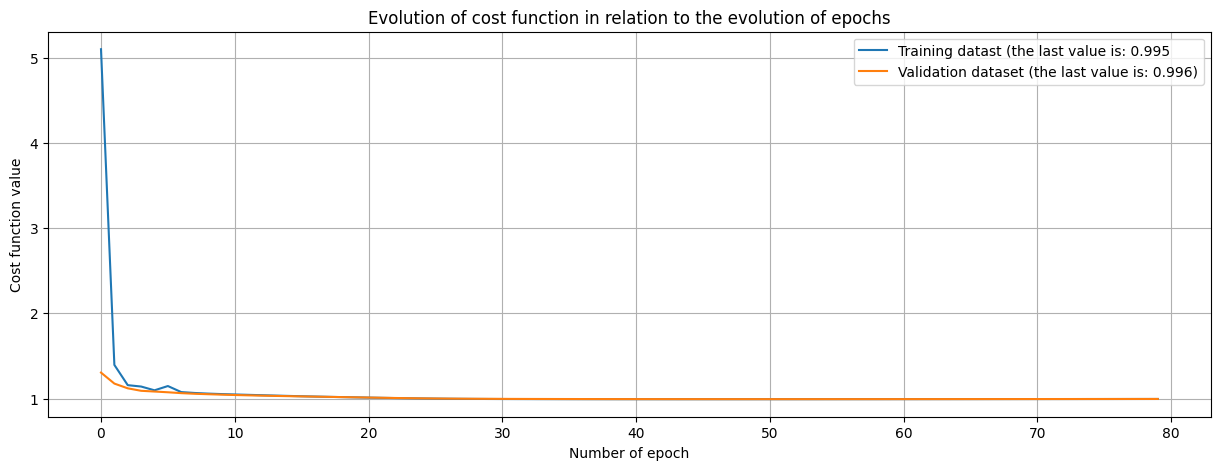

In [13]:
plt.figure(figsize=(15,5))
plt.plot(cost_train, label = f'Training datast (the last value is: {np.round(cost_train[-1], 3)}')
plt.plot(cost_val, label = f'Validation dataset (the last value is: {np.round(cost_val[-1], 3)})')
plt.legend()
plt.title('Evolution of cost function in relation to the evolution of epochs')
plt.ylabel('Cost function value')
plt.xlabel('Number of epoch')
plt.grid()
plt.show()

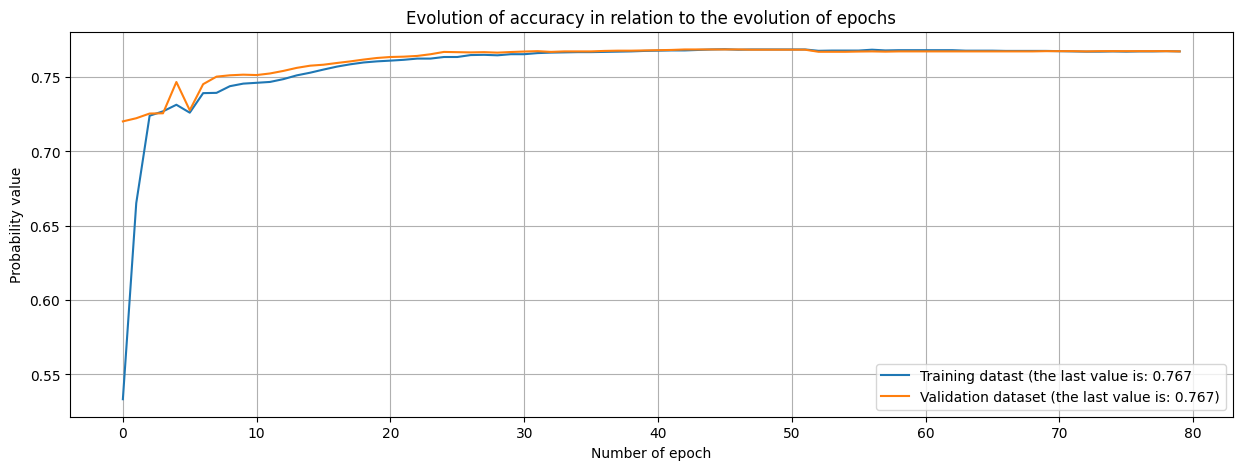

In [14]:
plt.figure(figsize=(15,5))
plt.plot(accuracy_train, label = f'Training datast (the last value is: {np.round(accuracy_train[-1], 3)}')
plt.plot(accuracy_val, label = f'Validation dataset (the last value is: {np.round(accuracy_val[-1], 3)})')
plt.legend()
plt.title('Evolution of accuracy in relation to the evolution of epochs')
plt.ylabel('Probability value')
plt.xlabel('Number of epoch')
plt.grid()
plt.show()

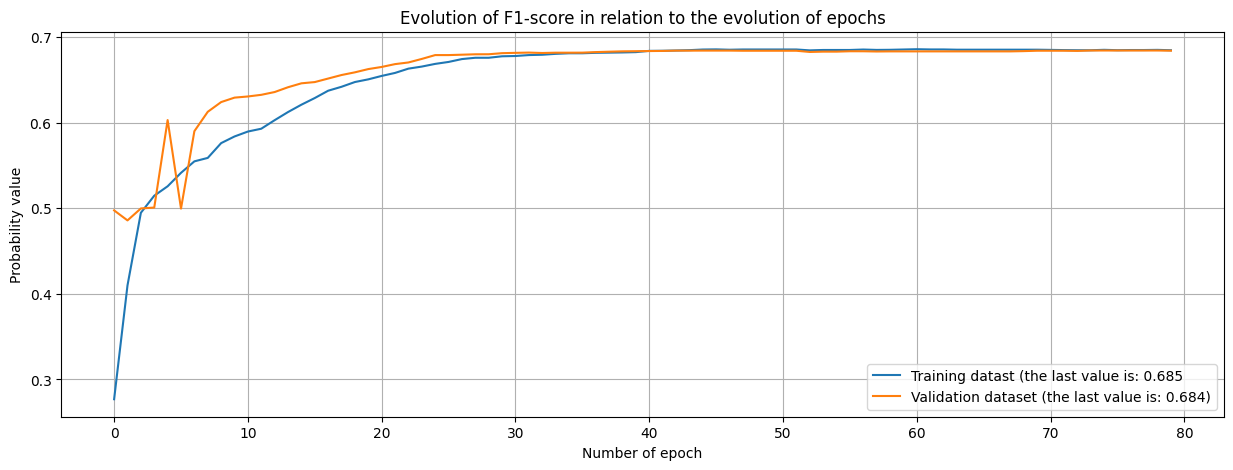

In [15]:
plt.figure(figsize=(15,5))
plt.plot(macro_f1_train, label = f'Training datast (the last value is: {np.round(macro_f1_train[-1], 3)}')
plt.plot(macro_f1_val, label = f'Validation dataset (the last value is: {np.round(macro_f1_val[-1], 3)})')
plt.legend()
plt.title('Evolution of F1-score in relation to the evolution of epochs')
plt.ylabel('Probability value')
plt.xlabel('Number of epoch')
plt.grid()
plt.show()


In [16]:
# test with test data
prediction = mlp.prediction(X_test)


In [17]:
# Folosim obiectul encoder! definit mai sus, pentru a obtine One-Hot Decoding
Y_test_decodered = encoder.inverse_transform(Y_test)
prediction_decodered = encoder.inverse_transform(prediction)

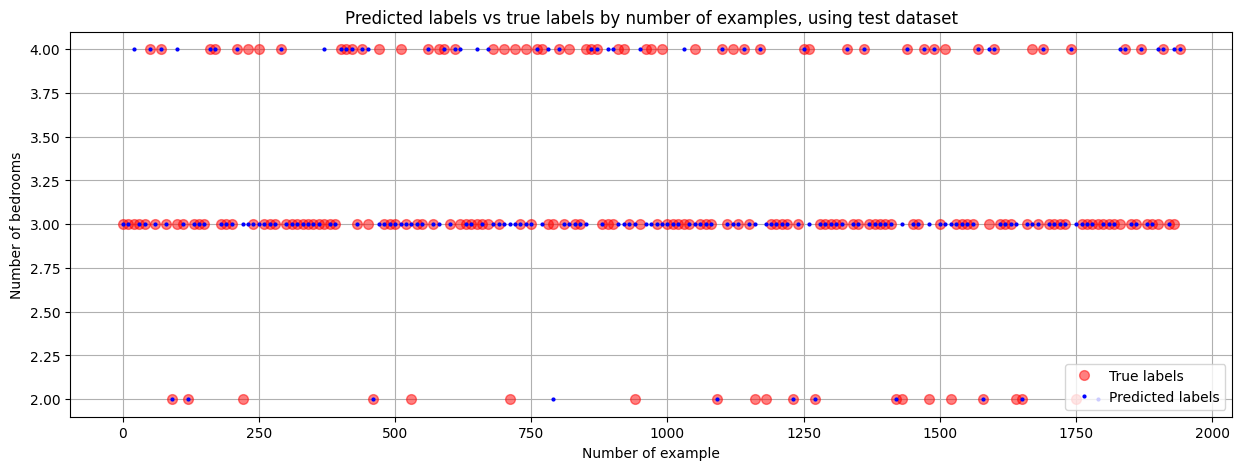

In [18]:
# Listeaza predictia si etichetele
step = 10 # pasul de afisare, pentru a nu aglomera graficul
len_step = range(len(Y_test_decodered))[0:-1: step] # vectorul care contine numarul corespondent epoci
Y_test_decodered_step = Y_test_decodered[0:-1: step] # vectorul cu etichete adevarate
prediction_decodered_step = prediction_decodered[0:-1: step] # vectorul cu etichete prezise

plt.figure(figsize=(15,5))
plt.plot(len_step, Y_test_decodered_step, 'o', markersize=7, color='red', alpha=0.5, label='True labels')
plt.plot(len_step, prediction_decodered_step, 'o', markersize=2, color='blue', label = 'Predicted labels')
plt.legend()
plt.title('Predicted labels vs true labels by number of examples, using test dataset')
plt.ylabel('Number of bedrooms')
plt.xlabel('Number of example')
plt.grid()
plt.show()

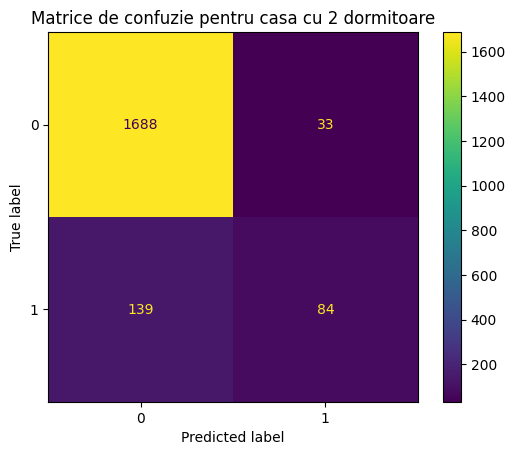

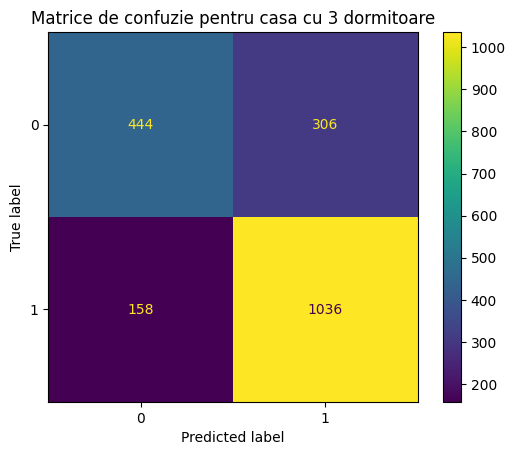

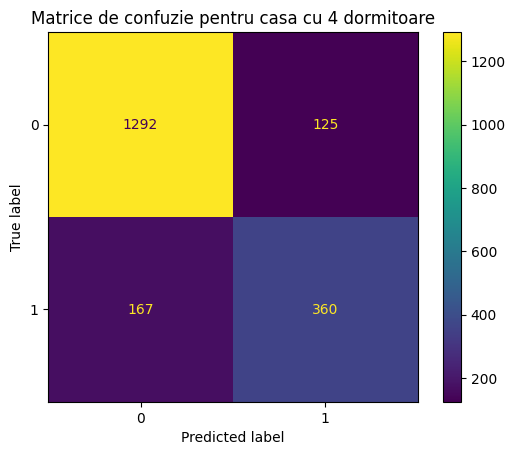

In [19]:
# Genereza matricea de confuzie
mcm = multilabel_confusion_matrix(Y_test, prediction)

# Listeaza matricea de confuzie pentru fiecare caz in parte
for i, matrix in enumerate(mcm):
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix)
    disp.plot()
    plt.title(f'Matrice de confuzie pentru casa cu {i+np.min(y)} dormitoare') # i+np.nin(y) deoarece minimul de dormitoare in acest caz este 2
    plt.show()

In [20]:
# Returneaza un raport a metricilor: Precision, Recall, F1-score 
report  = classification_report(Y_test, prediction)
print(report)
print('Positions 0, 1 and 2 correspond to 2, 3 and 4 bedrooms')

              precision    recall  f1-score   support

           0       0.72      0.38      0.49       223
           1       0.77      0.87      0.82      1194
           2       0.74      0.68      0.71       527

   micro avg       0.76      0.76      0.76      1944
   macro avg       0.74      0.64      0.67      1944
weighted avg       0.76      0.76      0.75      1944
 samples avg       0.76      0.76      0.76      1944

Positions 0, 1 and 2 correspond to 2, 3 and 4 bedrooms
